In [ ]:
# boxplots for matched cluster-subclass pairs

In [2]:
library(dplyr)
library(ggplot2)
library(ggrepel)
library(ggbeeswarm)
library(gridExtra)
library(ggridges)

In [46]:
# mapping mouse subclass vs sestan cluster
currdata = 'Caglayan'
treeshrew_mapdf = read.delim('tree_shrew_subclass_mapping.csv', sep = ',')
treeshrew_mapdf[1:2,]

mapdf = read.delim(paste0('mouse_primate_', currdata, '_mapping.csv'), sep = ',')
tail(mapdf)

,cluster,subclass,class
,<int>,<chr>,<chr>
1,1,Lamp5 Lhx6,CGE
2,4,Pvalb,MGE


,cluster,subclass,class
,<int>,<chr>,<chr>
24,12,Chandelier,MGE
25,9,Lamp5 Lhx6,CGE
26,28,Sst Chodl,MGE
27,2,Lamp5,CGE
28,14,Lamp5,CGE
29,27,Lamp5,CGE


In [16]:
# plot for all nhp species
path1 = paste0('/vault/suresh/consensus_interneuron_taxonomy/', tolower(currdata), '/')
if(currdata=='Sestan'){
    spes = c('human', 'chimp', 'macaque', 'marmoset', 'tree_shrew', 'mouse')
    spes2 = c('primate', 'primate', 'primate', 'primate', 'tree_shrew', 'mouse')
}else{
    spes = c('human', 'chimp', 'macaque', 'tree_shrew', 'mouse')    
    spes2 = c('primate', 'primate', 'primate', 'tree_shrew', 'mouse')
}


newdf = c()
combos = combn(spes, 2)

sp1_ctype = 'cluster'
sp2_ctype = sp1_ctype

for(ii in 1:(dim(combos)[2]-1)){   
    sp1 = combos[1,ii]
    sp2 = combos[2,ii]

    if(sp2=='tree_shrew' & sp2_ctype=='subclass'){
        file1 = paste0(path1, sp1, '_', sp2, '_subclass_', tolower(currdata), '_marker_paralogs_biomart.csv')
        file2 = paste0(path1, sp2, '_subclass_', sp1, '_', tolower(currdata), '_marker_paralogs_biomart.csv')
    }else if(sp2=='tree_shrew' & sp2_ctype!='subclass'){
        file1 = paste0(path1, sp1, '_', sp2, '_cluster_', tolower(currdata), '_marker_paralogs_biomart.csv')
        file2 = paste0(path1, sp2, '_cluster_', sp1, '_', tolower(currdata), '_marker_paralogs_biomart.csv')
    }else{
        file1 = paste0(path1, sp1, '_', sp2, '_', tolower(currdata), '_marker_paralogs_biomart.csv')
        file2 = paste0(path1, sp2, '_', sp1, '_', tolower(currdata), '_marker_paralogs_biomart.csv')
    }

    
    if(file.exists(file1)){
        temp = read.delim(file1, sep = ',')
    }else{
        temp = read.delim(file2, sep = ',')
        cols1 = colnames(temp)
        temp <- temp[,c(2,1,3,5,4,6)]
        colnames(temp) <- cols1
    }

    
    temp$species1 = sp1
    temp$species2 = sp2

    temp$spe_group1 = spes2[match(sp1, spes)]
    temp$spe_group2 = spes2[match(sp2, spes)]

    if(temp$spe_group1[1]=='primate'){
        temp$subclass1 = mapdf$subclass[match(temp$cluster1, mapdf$cluster)]
    }else if(temp$species1[1]=='tree_shrew' & sp1_ctype!='subclass'){
        temp$subclass1 = treeshrew_mapdf$subclass[match(temp$cluster1, treeshrew_mapdf$cluster)]
        temp$cluster1 <- temp$subclass1
    }else{
        temp$subclass1 = temp$cluster1
    }

    if(temp$spe_group2[1]=='primate'){
        temp$subclass2 = mapdf$subclass[match(temp$cluster2, mapdf$cluster)]
    }else if(temp$species2[1]=='tree_shrew' & sp2_ctype!='subclass'){
        temp$subclass2 = treeshrew_mapdf$subclass[match(temp$cluster2, treeshrew_mapdf$cluster)]
        temp$cluster2 <- temp$subclass2
    }else{
        temp$subclass2 = temp$cluster2
    }

    # load paralog enrichment
    if(sp2 == 'tree_shrew' & sp2_ctype == 'subclass'){
        paradf = read.delim(paste0(path1, sp1, '_', sp2, '_subclass_', tolower(currdata), '_paralog_enrichment.csv'), 
            sep = ',')
    }else if(sp2 == 'tree_shrew' & sp2_ctype != 'subclass'){
        paradf = read.delim(paste0(path1, sp1, '_', sp2, '_cluster_', tolower(currdata), '_paralog_enrichment.csv'), 
            sep = ',')
    }else{
        paradf = read.delim(paste0(path1, sp1, '_', sp2, '_', tolower(currdata), '_paralog_enrichment.csv'), 
                sep = ',')
    }
    colnames(paradf)[1:2] = c('cluster1', 'cluster2')
    temp$pval = paradf$pval
    temp$odds = paradf$odds

    # BH correction on all pairwise comparisons for a pair of species
    temp$p_adjust = p.adjust(temp$pval, method = 'BH')

    newdf = rbind(newdf, temp)
}

# distance betn clusters by nbd
newdf$dist = 1
newdf$dist[newdf$cluster1 == newdf$cluster2] = 0
newdf$dist[(newdf$subclass1 == newdf$subclass2) & (newdf$spe_group1=='primate' & newdf$spe_group2!='primate')] = 0

newdf2 = newdf %>% group_by(cluster1, cluster2, species1, species2, spe_group1, spe_group2,
                 subclass1, subclass2, dist) %>% reframe(shared = mean(shared, na.rm = T),
                                                  paralog1 = mean(paralog1, na.rm = T),
                                                 paralog2 = mean(paralog2, na.rm = T),
                                                 paralogs = mean(paralogs, na.rm = T),
                                                        pval = mean(pval, na.rm = T),
                                                        odds = mean(odds, na.rm = T),
                                                        p_adjust = mean(p_adjust, na.rm = T))
head(newdf2)

cluster1,cluster2,species1,species2,spe_group1,spe_group2,subclass1,subclass2,dist,shared,paralog1,paralog2,paralogs,pval,odds,p_adjust
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,chimp,macaque,primate,primate,Pvalb,Pvalb,0,44,10,7,8.5,5.622449e-05,6.809794,5.883553e-05
0,0,chimp,marmoset,primate,primate,Pvalb,Pvalb,0,47,11,9,10.0,5.706476e-07,9.339173,6.344701e-07
0,0,human,chimp,primate,primate,Pvalb,Pvalb,0,51,11,8,9.5,1.580845e-07,10.879046,1.845684e-07
0,0,human,macaque,primate,primate,Pvalb,Pvalb,0,56,8,4,6.0,2.796941e-04,7.524139,2.843206e-04
0,0,human,marmoset,primate,primate,Pvalb,Pvalb,0,53,11,5,8.0,8.917557e-06,9.037674,9.448697e-06
0,0,macaque,marmoset,primate,primate,Pvalb,Pvalb,0,49,6,6,6.0,1.157688e-03,5.628009,1.161123e-03


In [17]:
# plot stuff
celltype_color_palette = c("Chandelier"='#F641A8', "Pvalb"='#D93137', "Sst"='#FF9900', 
                           "Sst Chodl"='#FFD700', "Lamp5"='#DA808C', "Sncg"='#DF70FF',
                           "Vip"='#A45FBF', "Lamp5 Lhx6"='#935F50', "Pax6"='#71238C', 'NA' = 'grey90',
                          "intermediate_cls"='#37FD12')

if(currdata=='Sestan'){
    ancs = '17'
}else{
    ancs = '20'
}

plotdf = newdf2[newdf2$dist==0,]
plotdf1 <- plotdf[plotdf$species1=='human' & plotdf$cluster1!=ancs,]

plotdf2 = plotdf[plotdf$species1=='human' & plotdf$cluster1==ancs,]
plotdf2

cluster1,cluster2,species1,species2,spe_group1,spe_group2,subclass1,subclass2,dist,shared,paralog1,paralog2,paralogs,pval,odds,p_adjust
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
17,17,human,chimp,primate,primate,Vip,Vip,0,78,1,2,1.5,6.462653e-02,5.186425,6.462653e-02
17,17,human,macaque,primate,primate,Vip,Vip,0,55,8,10,9.0,5.503505e-07,11.118679,6.526963e-07
17,17,human,marmoset,primate,primate,Vip,Vip,0,44,8,12,10.0,3.670332e-07,9.763755,4.149070e-07
17,Vip,human,mouse,primate,mouse,Vip,Vip,0,7,27,23,25.0,2.197295e-05,4.831084,3.116164e-05
17,Vip,human,tree_shrew,primate,tree_shrew,Vip,Vip,0,18,23,28,25.5,7.003033e-09,7.967168,8.104401e-09


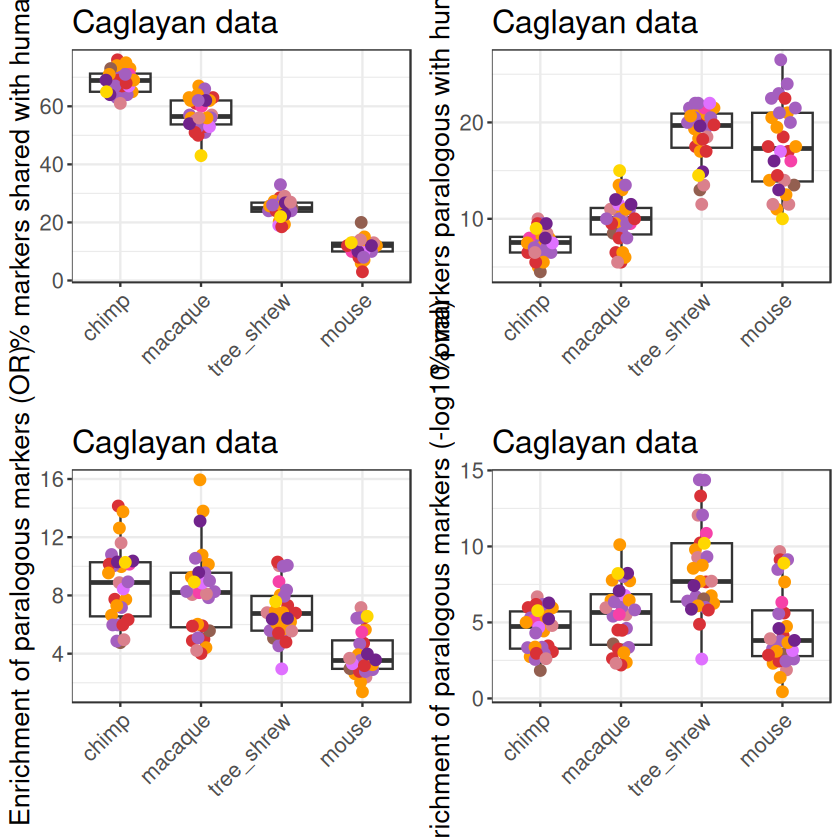

In [41]:
plotdf1$species2 = factor(plotdf1$species2, levels = spes)

# png(paste0('aa-', currdata, '-4panel-summary.png'), width = 10, height = 10, res = 300, units = 'in')
# pdf(paste0('aa-', currdata, '-4panel-summary.pdf'), width = 10, height = 10)
p1 <- ggplot(plotdf1, aes(x = species2, y = shared)) + geom_boxplot() +
geom_quasirandom(aes(color = subclass1), width = 0.2, shape = 16, size = 3) +
scale_color_manual(values = celltype_color_palette) + theme_bw() + theme(legend.position = 'none') +
xlab('') + ggtitle(paste0(currdata, ' data')) +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 45, hjust = 1)) +
ylab('% markers shared with human')

p2 <- ggplot(plotdf1, aes(x = species2, y = paralogs)) + geom_boxplot() +
geom_quasirandom(aes(color = subclass1), width = 0.2, shape = 16, size = 3) +
scale_color_manual(values = celltype_color_palette) + theme_bw() + theme(legend.position = 'none') +
xlab('') + ggtitle(paste0(currdata, ' data')) +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 45, hjust = 1)) +
ylab('% markers paralogous with human')

p3 <- ggplot(plotdf1, aes(x = species2, y = odds)) + geom_boxplot() +
geom_quasirandom(aes(color = subclass1), width = 0.2, shape = 16, size = 3) +
scale_color_manual(values = celltype_color_palette) + theme_bw() + theme(legend.position = 'none') +
xlab('') + ggtitle(paste0(currdata, ' data')) +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 45, hjust = 1)) +
ylab('Enrichment of paralogous markers (OR)')

p4 <- ggplot(plotdf1, aes(x = species2, y = -log10(p_adjust))) + geom_boxplot() +
geom_quasirandom(aes(color = subclass1), width = 0.2, shape = 16, size = 3) +
scale_color_manual(values = celltype_color_palette) + theme_bw() + theme(legend.position = 'none') +
xlab('') + ggtitle(paste0(currdata, ' data')) +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 45, hjust = 1)) +
ylab('Enrichment of paralogous markers (-log10 pval)')

grid.arrange(p1, p2, p3, p4, nrow = 2)

# dev.off()

In [8]:
# plot paralog/ortholog ratio for select clusters in diff species - x : Vip, y : Sncg

In [19]:
celltype1 = 'Sncg'
celltype2 = 'Vip'
sncg = mapdf$cluster[mapdf$subclass==celltype1]
vips = setdiff(mapdf$cluster[mapdf$subclass==celltype2], ancs)

In [20]:
# get number of shared and paralogous markers with Vip/Sncg
# for human Vip + Sncg clusters against clusters from another species

get_prop_vip_sncg <- function(newdf, sp1, sp2){
    plotdf <- newdf[newdf$species1==sp1 & newdf$species2==sp2,]
    max_orthologs = max(plotdf$shared, na.rm = T)
    max_paralogs = max(plotdf$paralogs, na.rm = T)
    
    plotdf <- plotdf[plotdf$cluster1 %in% c(ancs, sncg, vips),]
    plotdf <- plotdf[plotdf$subclass2 %in% c(celltype2, celltype1),]
    
    plotdf$ctype = celltype2
    plotdf$ctype[plotdf$cluster1==ancs] = 'intermediate_cls'
    plotdf$ctype[plotdf$cluster1 %in% sncg] = celltype1
    # plotdf[1:4,]
    
    df1 = plotdf %>% group_by(cluster1, subclass2) %>% reframe(shared = mean(shared, na.rm = T),
                                              paralog = mean(paralogs, na.rm = T))
    
    # # for plotting, get vip and sncg - shared orthologs into two columns
    plotdf2 = data.frame(cluster = unique(df1$cluster1), max_orthologs, max_paralogs)
    plotdf2$ctype = plotdf$ctype[match(plotdf2$cluster, plotdf$cluster1)]
    
    plotdf2$vip_ortholog = df1$shared[df1$subclass2==celltype2]
    plotdf2$vip_paralog = df1$paralog[df1$subclass2==celltype2]
    
    plotdf2$sncg_ortholog = df1$shared[df1$subclass2==celltype1]
    plotdf2$sncg_paralog = df1$paralog[df1$subclass2==celltype1]
    return(plotdf2)
}

In [21]:
sp1 = 'human'

if(currdata=='Sestan'){
    spes = c('chimp', 'macaque', 'marmoset', 'tree_shrew', 'mouse')
}else{
    spes = c('chimp', 'macaque', 'tree_shrew', 'mouse')    
}

plotdf2 = c()
for(ii in 1:length(spes)){
    sp2 = spes[ii]
    temp = get_prop_vip_sncg(newdf2, sp1, sp2)
    temp$species = sp2
    plotdf2 = rbind(plotdf2, temp)
}

plotdf2$species = factor(plotdf2$species, levels = spes)
plotdf2[1:2,]

,cluster,max_orthologs,max_paralogs,ctype,vip_ortholog,vip_paralog,sncg_ortholog,sncg_paralog,species
,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,4,78,30,Vip,37.66667,11.75,19.5,15.5,chimp
2,9,78,30,Vip,42.16667,11.75,25.5,18.0,chimp


In [23]:
plotdf2$species = factor(plotdf2$species, levels = rev(spes))
plotdf2$ctype = factor(plotdf2$ctype, levels = c('intermediate_cls', celltype1, celltype2))

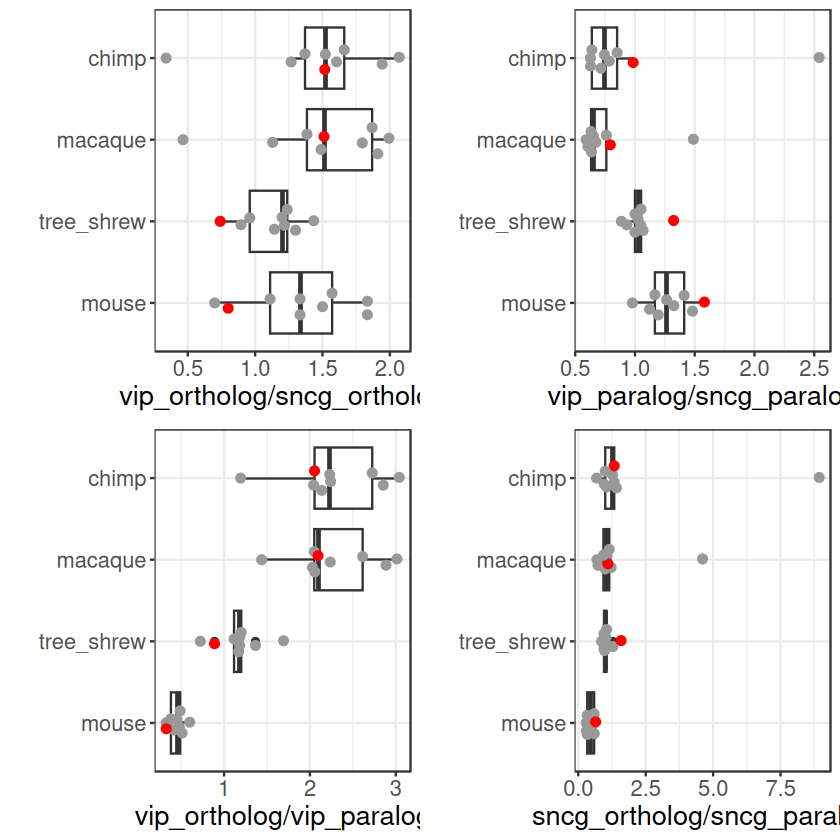

In [37]:
# png(paste0('aa-', currdata, '-cls-marginal-distr.png'), width = 10, height = 10, res = 300, units = 'in')
p1 <- ggplot(plotdf2, aes(x = vip_ortholog/sncg_ortholog, y = species)) + geom_boxplot() + 
geom_quasirandom(aes(color = ctype), width = 0.2, shape = 16, size = 2.5, orientation = 'y') + 
theme_bw() + theme(legend.position = 'none') + ylab('') + theme(text = element_text(size = 16)) +
scale_color_manual(values = c('red', '#999999', '#999999'))

p2 <- ggplot(plotdf2, aes(x = vip_paralog/sncg_paralog, y = species)) + geom_boxplot() + 
geom_quasirandom(aes(color = ctype), width = 0.2, shape = 16, size = 2.5, orientation = 'y') + 
theme_bw() + theme(legend.position = 'none') + ylab('') + theme(text = element_text(size = 16)) +
scale_color_manual(values = c('red', '#999999', '#999999'))

p3 <- ggplot(plotdf2, aes(x = vip_ortholog/vip_paralog, y = species)) + geom_boxplot() + 
geom_quasirandom(aes(color = ctype), width = 0.2, shape = 16, size = 2.5, orientation = 'y') + 
theme_bw() + theme(legend.position = 'none') + ylab('') + theme(text = element_text(size = 16)) +
scale_color_manual(values = c('red', '#999999', '#999999'))

p4 <- ggplot(plotdf2, aes(x = sncg_ortholog/sncg_paralog, y = species)) + geom_boxplot() + 
geom_quasirandom(aes(color = ctype), width = 0.2, shape = 16, size = 2.5, orientation = 'y') + 
theme_bw() + theme(legend.position = 'none') + ylab('') + theme(text = element_text(size = 16)) +
scale_color_manual(values = c('red', '#999999', '#999999')) 

grid.arrange(p1, p2, p3, p4, nrow = 2)
# dev.off()

Picking joint bandwidth of 0.164

Picking joint bandwidth of 0.0687



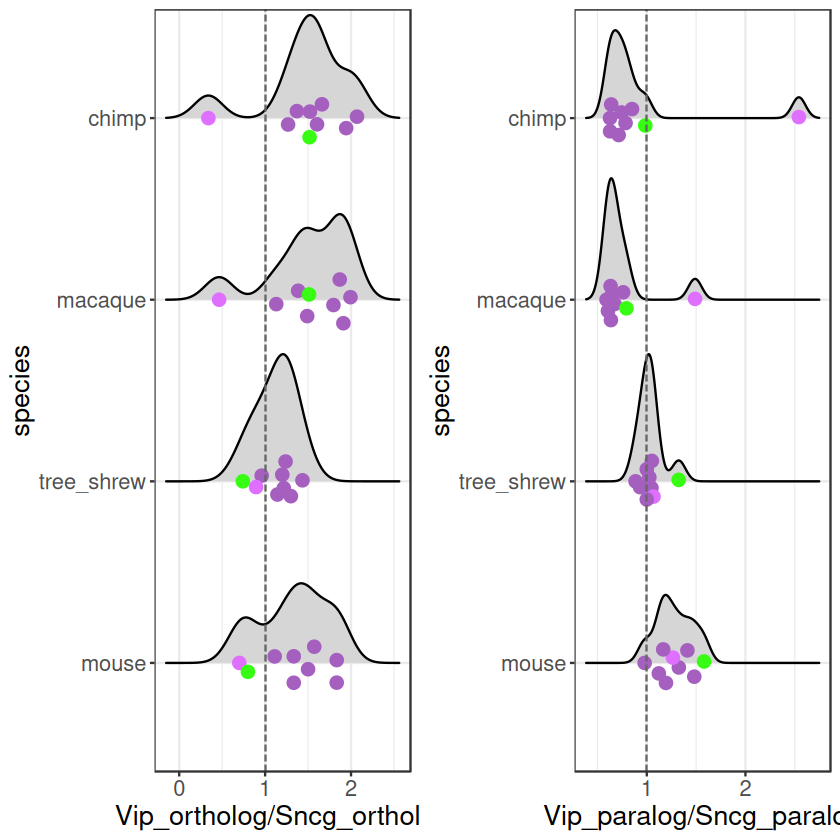

In [39]:
# png(paste0('aa-', currdata, '-', celltype1, '-vs-', celltype2, '.png'), width = 10, height = 5, res = 300, units = 'in')
# pdf(paste0('aa-', currdata, '-cls-marginal-riges.pdf'), width = 10, height = 5)
p1 <- ggplot(plotdf2, aes(x = vip_ortholog/sncg_ortholog, y = species)) + geom_density_ridges(scale = 0.7, fill = '#d6d6d6') + 
geom_quasirandom(aes(color = ctype), width = 0.15, shape = 16, size = 3.5, orientation = 'y') + theme_bw() +
theme(legend.position = 'none')+ theme(text = element_text(size = 16)) + 
geom_vline(xintercept = 1, colour = "#666666", linetype = "longdash") + xlab(paste0(celltype2, '_ortholog/', celltype1, '_ortholog')) +
scale_color_manual(values = c(celltype_color_palette["intermediate_cls"], celltype_color_palette[celltype1], celltype_color_palette[celltype2])) 

p2 <- ggplot(plotdf2, aes(x = vip_paralog/sncg_paralog, y = species)) + geom_density_ridges(scale = 0.7, fill = '#d6d6d6') + 
geom_quasirandom(aes(color = ctype), width = 0.15, shape = 16, size = 3.5, orientation = 'y') + theme_bw() +
theme(legend.position = 'none')+ theme(text = element_text(size = 16)) +
geom_vline(xintercept = 1, colour = "#666666", linetype = "longdash") + xlab(paste0(celltype2, '_paralog/', celltype1, '_paralog')) +
scale_color_manual(values = c(celltype_color_palette["intermediate_cls"], celltype_color_palette[celltype1], celltype_color_palette[celltype2])) 

grid.arrange(p1, p2, nrow = 1)
# dev.off()